You can order print and ebook versions of *Think Bayes 2e* from
[Bookshop.org](https://bookshop.org/a/98697/9781492089469) and
[Amazon](https://amzn.to/334eqGo).

# 5. Estimating Counts

In [ ]:
# Install empiricaldist if necessary
try:
    import empiricaldist
except ImportError:
    !pip install -q empiricaldist
    import empiricaldist

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# # Get utils.py
# from os.path import basename, exists

# def download(url):
#     filename = basename(url)
#     if not exists(filename):
#         from urllib.request import urlretrieve
#         local, _ = urlretrieve(url, filename)
#         print('Downloaded ' + local)

# download('https://github.com/AllenDowney/ThinkBayes2/raw/master/soln/utils.py')

In [ ]:
!wget https://github.com/AllenDowney/ThinkBayes2/raw/master/soln/utils.py

--2026-04-05 12:40:14--  https://github.com/AllenDowney/ThinkBayes2/raw/master/soln/utils.py
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkBayes2/master/soln/utils.py [following]
--2026-04-05 12:40:14--  https://raw.githubusercontent.com/AllenDowney/ThinkBayes2/master/soln/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11373 (11K) [text/plain]
Saving to: ‘utils.py’

utils.py            100%[===================>]  11.11K  --.-KB/s    in 0s      

2026-04-05 12:40:14 (44.9 MB/s) - ‘utils.py’ saved [11373/11373]



In [ ]:
from utils import set_pyplot_params

set_pyplot_params()

In the previous chapter we solved problems that involve estimating proportions.
In the Euro problem, we estimated the probability that a coin lands heads up, and in the exercises, you estimated a batting average, the fraction of people who cheat on their taxes, and the chance of shooting down an invading alien.

Clearly, some of these problems are more realistic than others, and some are more useful than others.

In this chapter, we'll work on problems related to counting, or estimating the size of a population.
Again, some of the examples will seem silly, but some of them, like the German Tank problem, have real applications, sometimes in life and death situations.

## 5.1 The Train Problem

I found the train problem
in Frederick Mosteller's, [*Fifty Challenging Problems in
  Probability with Solutions*](https://store.doverpublications.com/0486653552.html):

> "A railroad numbers its locomotives in order 1...N.  One day you see a locomotive with the number 60.  Estimate how many locomotives the railroad has."

Based on this observation, we know the railroad has 60 or more
locomotives.  But how many more?  To apply Bayesian reasoning, we
can break this problem into two steps:

* What did we know about $N$ before we saw the data?

* For any given value of $N$, what is the likelihood of seeing the data (a locomotive with number 60)?

The answer to the first question is the prior.  The answer to the
second is the likelihood.

We don't have much basis to choose a prior, so we'll start with
something simple and then consider alternatives.
Let's assume that $N$ is equally likely to be any value from 1 to 1000.

Here's the prior distribution:

In [ ]:
import numpy as np
from empiricaldist import Pmf

hypos = np.arange(1, 1001)
prior = Pmf(1, hypos)
prior.normalize()
prior

,0
1,0.001
2,0.001
3,0.001
4,0.001
5,0.001
...,...
996,0.001
997,0.001
998,0.001
999,0.001



Now let's figure out the likelihood of the data.
In a hypothetical fleet of $N$ locomotives, what is the probability that we would see number 60?
If we assume that we are equally likely to see any locomotive, the chance of seeing any particular one is $1/N$.

Here's the function that does the update:

In [ ]:
def update_train(pmf, data):
    """Update pmf based on new data."""
    hypos = pmf.qs
    likelihood = 1 / hypos
    impossible = (data > hypos)
    likelihood[impossible] = 0
    pmf *= likelihood
    pmf.normalize()

**Note:** When estimating a proportion, there were two separate NumPy arrays: (i) *"likelihood of vanilla / heads / success"*, and (ii) *"likelihood of chocolate / tails / failure"*. When estimating a count, there is just a single NumPy array: `likelihood` (of observing `data`). (We've previously encountered this problem structure in the "Dice Problem" section in Chapter 3, and in the "Binomial Likelihood Function" section in Chapter 4. In the latter, we calculated the likelihood of `"exactly 140 successes out of 250 trials"`, given each parameter value.)

This function might look familiar; it is the same as the update function for the "Dice Problem" in Chapter 3.
In terms of likelihood, the train problem is the same as the "Dice Problem".

Here's the update:

In [ ]:
data = 60
posterior = prior.copy()
update_train(posterior, data)

Here's what the posterior looks like:

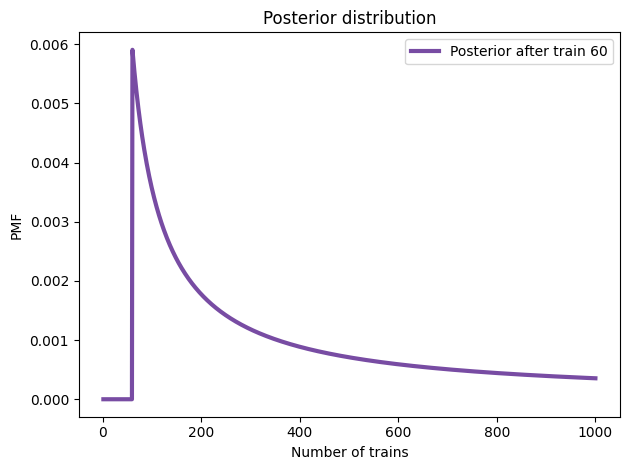

In [ ]:
from utils import decorate

posterior.plot(label='Posterior after train 60', color='C4')
decorate(xlabel='Number of trains', ylabel='PMF', title='Posterior distribution')

Not surprisingly, all values of $N$ below 60 have been eliminated.

The most likely value, if you had to guess, is 60.

In [ ]:
posterior.max_prob()

np.int64(60)

In [ ]:
3*17 + 2*15 + 3*20 + 2*14

169

That might not seem like a very good guess; after all, what are the chances that you just happened to see the train with the highest number?
Nevertheless, if you want to maximize the chance of getting
the answer exactly right, you should guess 60.

But maybe that's not the right goal.
An alternative is to compute the mean of the posterior distribution.
Given a set of possible quantities, $q_i$, and their probabilities, $p_i$, the mean (a.k.a. *expected value* and *expectation*) of the distribution is:

$$\mathrm{mean} = \sum_i p_i q_i$$

---

Some background:-

**Frequency distribution:** https://www.cuemath.com/data/frequency-distribution/

**Why relative frequencies can be interpreted as probabilities if n is large and observations are i.i.d.:** https://chatgpt.com/share/69cd7117-1734-83a5-b9e1-c7273b795217

**Sample mean vs. population mean (expectation):** See the first part of https://chatgpt.com/share/69d0bab7-4458-83a3-a23f-0b26b26dd8db

**Why expectation pertains to a single trial, and yet is considered an average:** https://chatgpt.com/share/69cd68fb-2c5c-83aa-8824-7e72fa8601f3

**Law of Large Numbers:** https://en.wikipedia.org/wiki/Law_of_large_numbers

According to the Law of Large Numbers, if we sample a large number of values from the posterior distribution, the sample average will tend towards the expected value.

---

We can compute the expected value like this:

In [ ]:
np.sum(posterior.ps * posterior.qs)

np.float64(333.4198932637079)

Or we can use the method provided by `Pmf`:

In [ ]:
posterior.mean()

np.float64(333.4198932637079)

The mean of the posterior is 333, so that might be a good guess if you want to minimize error.
If you played this guessing game over and over, using the mean of the posterior as your estimate would minimize the [mean squared error](http://en.wikipedia.org/wiki/Minimum_mean_square_error) over the long run.

## 5.2 Sensitivity to the Prior

The prior I used in the previous section is uniform from 1 to 1000, but I offered no justification for choosing a uniform distribution or that particular upper bound.
We might wonder whether the posterior distribution is sensitive to the prior.
With so little data---only one observation---it is.

This table shows what happens as we vary the upper bound:

In [ ]:
import pandas as pd

df = pd.DataFrame(columns=['Posterior mean'])
df.index.name = 'Upper bound'
df

,Posterior mean
Upper bound,


In [ ]:
for high in [500, 1000, 2000]:
    hypos = np.arange(1, high + 1)
    pmf = Pmf(1, hypos)
    pmf.normalize()
    update_train(pmf, data=60)
    df.loc[high] = pmf.mean()

df

,Posterior mean
Upper bound,
500,207.079228
1000,333.419893
2000,552.179017


As we vary the upper bound, the posterior mean changes substantially.
So that's bad.  

When the posterior is sensitive to the prior, there are two ways to proceed:

* Get more data.

* Get more background information and choose a better prior.

With more data, posterior distributions based on different priors tend to converge.  
For example, suppose that in addition to train 60 we also see trains 30 and 90.

Here's how the posterior means depend on the upper bound of the prior, when we observe three trains:

In [ ]:
df = pd.DataFrame(columns=['Posterior mean'])
df.index.name = 'Upper bound'

dataset = [30, 60, 90]

for high in [500, 1000, 2000]:
    hypos = np.arange(1, high + 1)
    pmf = Pmf(1, hypos)
    pmf.normalize()
    for data in dataset:
        update_train(pmf, data)
    df.loc[high] = pmf.mean()

df

,Posterior mean
Upper bound,
500,151.849588
1000,164.305586
2000,171.338181


The differences are smaller, but apparently three trains are not enough for the posteriors to converge.

**Note:** Here, the assumption is that we're sampling with replacement. In other words, we may observe train 60 more than once. But in the "German Tank Problem" (https://en.wikipedia.org/wiki/German_tank_problem), it's a case of sampling without replacement (supposedly because the observations are obtained from tanks captured in battle). In this case, the likelihoods become stateful, because each observation changes the composition of tanks left in the *block* of 100 serial numbers. For example, let's say that one (of the 100) hypotheses is that there are 50 tanks in a particular block. Given this hypothesis, the likelihood of observing one tank is 1/50 at the beginning. But after one observation, the likelihood reduces to 1/49. Since the observations aren't conditionally independent anymore (given the parameter N), the order of Bayesian updates will affect the posterior distribution.

## 5.3 Power Law Prior

If more data are not available, another option is to improve the
priors by gathering more background information.
It is probably not reasonable to assume that a train-operating company with 1000 locomotives is just as likely as a company with only 1.

With some effort, we could probably find a list of companies that
operate locomotives in the area of observation.
Or we could interview an expert in rail shipping to gather information about the typical size of companies.

But even without getting into the specifics of railroad economics, we
can make some educated guesses.
In most fields, there are many small companies, fewer medium-sized companies, and only one or two very large companies.

In fact, the distribution of company sizes tends to follow a power law, as Robert Axtell reports in *Science* (<http://www.sciencemag.org/content/293/5536/1818.full.pdf>).

This law suggests that if there are 1000 companies with fewer than
10 locomotives, there might be 100 companies with 100 locomotives,
10 companies with 1000, and possibly one company with 10,000 locomotives.

- 1000 companies => "high probability"
- 100 companies => "medium probability"
- 10 companies => "low probability"
- 1 company => "extremely low probability"

Mathematically, a power law means that the number of companies with a given size, $N$, is proportional to $(1/N)^{\alpha}$, where $\alpha$ is a parameter that is often near 1.

**Note:** The number of companies with a given size, $N$, affects the probability of encountering a company with a given size, $N$.

We can construct a power law prior like this:

In [ ]:
# Reminder:
hypos

array([   1,    2,    3, ..., 1998, 1999, 2000])

In [ ]:
alpha = 1.0
ps = hypos**(-alpha)
power = Pmf(ps, hypos, name='power law')
power.normalize()
power

,power law
1,0.122274
2,0.061137
3,0.040758
4,0.030568
5,0.024455
...,...
1996,0.000061
1997,0.000061
1998,0.000061
1999,0.000061


For comparison, here's the uniform prior again.

In [ ]:
hypos = np.arange(1, 1001)
uniform = Pmf(1, hypos, name='uniform')
uniform.normalize()
uniform

,uniform
1,0.001
2,0.001
3,0.001
4,0.001
5,0.001
...,...
996,0.001
997,0.001
998,0.001
999,0.001


Here's what a power law prior looks like, compared to the uniform prior:

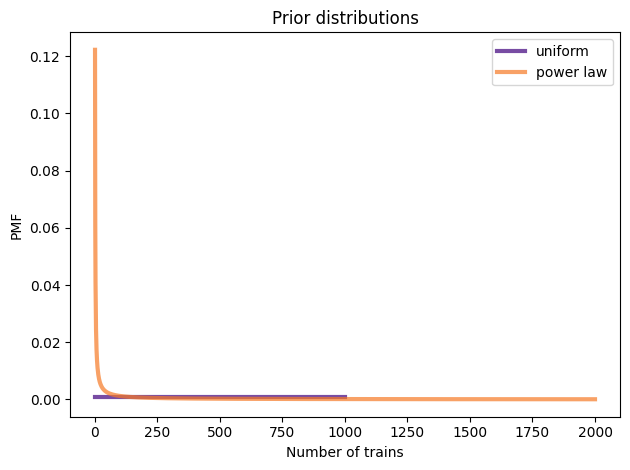

In [ ]:
uniform.plot(color='C4')
power.plot(color='C1')

decorate(xlabel='Number of trains', ylabel='PMF', title='Prior distributions')

Here's the update for both priors.

In [ ]:
data = 60
update_train(uniform, data)
update_train(power, data)

And here are the posterior distributions.

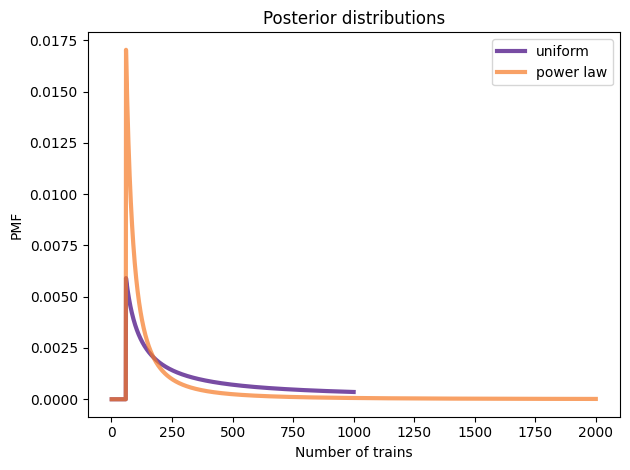

In [ ]:
uniform.plot(color='C4')
power.plot(color='C1')

decorate(xlabel='Number of trains', ylabel='PMF', title='Posterior distributions')

In [ ]:
uniform.mean(), power.mean()

(np.float64(333.4198932637079), np.float64(215.56892550615524))

The power law prior assigns more prior probability to low values, and less prior probability to high values. This yields a lower posterior mean, compared to the uniform prior.

Using the power law prior results in less sensitivity to the upper bound. Here's how the posterior means depend on the upper bound when we use a power law prior and observe three trains:

In [ ]:
df = pd.DataFrame(columns=['Posterior mean'])
df.index.name = 'Upper bound'

alpha = 1.0
dataset = [30, 60, 90]

for high in [500, 1000, 2000]:
    hypos = np.arange(1, high + 1)
    ps = hypos**(-alpha)
    power = Pmf(ps, hypos)
    power.normalize()
    for data in dataset:
        update_train(power, data)
    df.loc[high] = power.mean()

df

,Posterior mean
Upper bound,
500,130.708470
1000,133.275231
2000,133.997463


Now the differences are much smaller.  In fact,
with an arbitrarily large upper bound, the mean converges on 134.

So the power law prior is more realistic, because it is based on
general information about the size of companies, and it behaves better in practice.

## 5.4 Credible Intervals

So far we have seen two ways to summarize a posterior distribution: the value with the highest posterior probability (the MAP) and the posterior mean.
These are both **point estimates**, that is, single values that estimate the quantity we are interested in.

Another way to summarize a posterior distribution is with percentiles.
If you have taken a standardized test, you might be familiar with percentiles.
For example, if your score is the 90th percentile, that means you did as well as or better than 90\% of the people who took the test.

If we are given a value, `x`, we can compute its **percentile rank** by finding all values less than or equal to `x` and adding up their probabilities.

---

**Note:** In descriptive statistics, a quantile (and its more specialized forms such as median, quartile and percentile) of a dataset is calculated using *just* the sorted values. This is because all the observations in a dataset are considered equally likely. However, in the context of a PMF, all the outcome values aren't equally likely. Therefore, the notion of a quantile changes in this context. The `0.9` quantile (90th percentile) is the smallest value `x` for which 90% of the probability mass lies below or at that value. (Here, the input is `0.9`, and the output is the value `x`.) On the other hand, the *percentile rank* of a value `x` is the sum of probability masses of all values that are less than or equal to `x`. For example, in the below example, the percentile rank of `100` is `0.29`. (Here, the input is the value `100`, and the output is the cumulative probability mass `0.29`.) More from ChatGPT on this: https://chatgpt.com/share/69aacc26-5140-8010-ab33-2f64c74f34e3

---

`Pmf` provides a method that does this computation.
So, for example, we can compute the probability that the company has less than or equal to 100 trains:

In [ ]:
power.prob_le(100)

np.float64(0.2937469222495771)

**Note:** We first encountered the `prob_ge` and `prob_le` methods of `Pmf` in Chapter 4.

With a power law prior and a dataset of three trains, the result is about 29%.
So 100 trains is the 29th percentile.

Going the other way, suppose we want to compute a particular percentile; for example, the median of a distribution is the 50th percentile.
We can compute it by adding up probabilities until the total exceeds 0.5.
Here's a function that does it:

In [ ]:
def quantile(pmf, prob):
    """Compute a quantile with the given prob threshold."""
    total = 0
    for q, p in pmf.items():
        total += p
        if total >= prob:
            return q
    return np.nan

The loop uses `items`, which iterates the quantities and probabilities in the distribution.
Inside the loop we add up the probabilities of the quantities in order.
When the total equals or exceeds `prob`, we return the corresponding quantity.

This function is called `quantile` because it computes a quantile rather than a percentile.
The difference is the way we specify `prob`.
If `prob` is a percentage between 0 and 100, we call the corresponding quantity a percentile.
If `prob` is a probability between 0 and 1, we call the corresponding quantity a **quantile**. (More from ChatGPT on this: https://chatgpt.com/share/69aacc26-5140-8010-ab33-2f64c74f34e3)

Here's how we can use this function to compute the 50th percentile of the posterior distribution:

In [ ]:
quantile(power, 0.5)

113

The result, 113 trains, is the median of the posterior distribution.

`Pmf` provides a method called `quantile` that does the same thing.
We can call it like this to compute the 5th and 95th percentiles:

In [ ]:
power.quantile([0.05, 0.95])

array([ 91., 243.])

The result is the interval from 91 to 243 trains, which implies:

* The probability is 5% that the number of trains is less than or equal to 91.

* The probability is 5% that the number of trains is greater than 243.

Therefore the probability is 90% that the number of trains falls between 91 and 243 (excluding 91 and including 243).
For this reason, this interval is called a 90% **credible interval**.

`Pmf` also provides `credible_interval`, which computes an interval that contains the given probability.

In [ ]:
power.credible_interval(0.9)

array([ 91., 243.])

In [ ]:
power.credible_interval(0.95)

array([ 90., 306.])

In [ ]:
power.credible_interval(0.99)

array([ 90., 520.])

## 5.5 The German Tank Problem

During World War II, the Economic Warfare Division of the American
Embassy in London used statistical analysis to estimate German
production of tanks and other equipment.

The Western Allies had captured log books, inventories, and repair
records that included chassis and engine serial numbers for individual
tanks.

Analysis of these records indicated that serial numbers were allocated
by manufacturer and tank type in blocks of 100 numbers, that numbers
in each block were used sequentially, and that not all numbers in each
block were used (i.e., 100 tanks weren't necessarily produced for each block).  So the problem of estimating German tank production
could be reduced, **within each block of 100 numbers**, to a form of the
train problem.

Based on this insight, American and British analysts produced
estimates substantially lower than estimates from other forms
of intelligence.  And after the war, records indicated that they were
substantially more accurate.

They performed similar analyses for tyres, trucks, rockets, and other
equipment, yielding accurate and actionable economic intelligence.

The German tank problem is historically interesting; it is also a nice
example of real-world application of statistical estimation.

For more on this problem, see [this Wikipedia page](https://en.wikipedia.org/wiki/German_tank_problem) and Ruggles and Brodie, "An Empirical Approach to Economic Intelligence in World War II", *Journal of the American Statistical Association*, March 1947, [available here](https://web.archive.org/web/20170123132042/https://www.cia.gov/library/readingroom/docs/CIA-RDP79R01001A001300010013-3.pdf).

## 5.6 Informative Priors

Among Bayesians, there are two approaches to choosing prior
distributions.  Some recommend choosing the prior that best represents
background information about the problem; in that case the prior
is said to be **informative**.  The problem with using an informative
prior is that people might have different information or
interpret it differently.  So informative priors might seem arbitrary.

The alternative is a so-called **uninformative prior**, which is
intended to be as unrestricted as possible, in order to let the data
speak for itself.  In some cases you can identify a unique prior
that has some desirable property, like representing minimal prior
information about the estimated quantity.

Uninformative priors are appealing because they seem more
objective.  But I am generally in favor of using informative priors.
Why?  First, Bayesian analysis is always based on
the modeler's decisions.  Choosing the prior is one of those decisions, but
it is not the only one, and it might not even be the most subjective.
So even if an uninformative prior is more objective, the entire analysis is still subjective. (See https://chatgpt.com/share/69cd02c6-46a4-83a6-8485-2076c0b912c3)

Also, for most practical problems, you are likely to be in one of two
situations: either you have a lot of data or not very much.  If you have a lot of data, the choice of the prior doesn't matter;
informative and uninformative priors yield almost the same results.
If you don't have much data, using relevant background information (like the power law distribution) makes a big difference.

And if, as in the German tank problem, you have to make life and death
decisions based on your results, you should probably use all of the
information at your disposal, rather than maintaining the illusion of
objectivity by pretending to know less than you do.

**Question:** How much information does a particular prior contribute? In other words, how to measure the informativeness of a prior? Which notion of information is most apt for answering this question? (See https://chatgpt.com/share/69ccfcf6-ba30-83a8-b5df-8e122e5139c8) Check Section 3.2 in the following paper: https://arxiv.org/abs/1705.01064

## 5.7 Summary

This chapter introduces the train problem, which turns out to have the same likelihood function as the dice problem, and which can be applied to the German tank problem.
In both the train problem and the German tank problem, the goal is to estimate a count, or the size of a population.

In the next chapter, I'll introduce "odds" as an alternative to probabilities, and Bayes's Rule as an alternative form of Bayes's Theorem.
We'll compute distributions of sums and products, and use them to estimate the number of Members of Congress who are corrupt, among other problems.

But first, you might want to work on these exercises.

## 5.8 Exercises

**Exercise:** Suppose you are giving a talk in a large lecture hall and the fire marshal interrupts because they think the audience exceeds 1200 people, which is the safe capacity of the room.

You think there are fewer then 1200 people, and you offer to prove it.
It would take too long to count, so you try an experiment:

* You ask how many people were born on May 11 and two people raise their hands.  

* You ask how many were born on May 23 and 1 person raises their hand.  
* Finally, you ask how many were born on August 1, and no one raises their hand.

How many people are in the audience?  What is the probability that there are more than 1200 people.
Hint: Remember the binomial distribution.

---

Let's say that our hypotheses are `1`, `2`, ..., `2000`, where `2000` is the (very liberally) assumed maximum capacity of the room.

In [ ]:
# Solution goes here
hypos = np.arange(1, 2001)

Let's go with a triangle prior, as values nearer to `1000` are more likely than values nearer to `0` or to `2000`.

In [ ]:
# Solution goes here
ramp_up = np.arange(1000)
ramp_down = np.arange(1000, 0, -1)
ps = np.append(ramp_up, ramp_down)
ps.shape

(2000,)

In [ ]:
# Solution goes here
prior = Pmf(ps, hypos)
prior.normalize()
prior

,0
1,0.000000
2,0.000001
3,0.000002
4,0.000003
5,0.000004
...,...
1996,0.000005
1997,0.000004
1998,0.000003
1999,0.000002


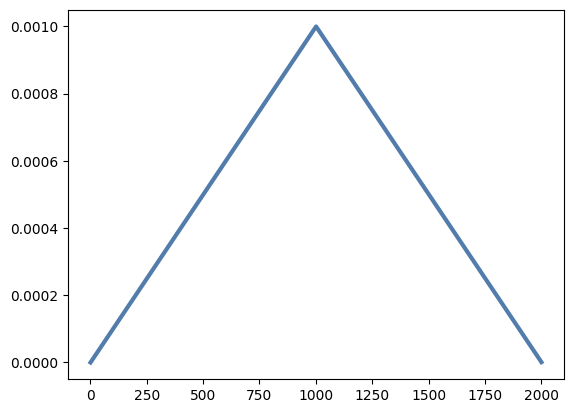

In [ ]:
# Solution goes here
prior.plot();

The first piece of data is that `2` people were born on May 11.

Let's consider being born on May 11 as a binary outcome. If being born on any day of the year is equally likely, then the parameter $p$ of this particular binomial distribution is `1/365`. And $1 - p$ is `364/365`. $k$ is `2`. There is one value of $n$ for each of the `2000` hypotheses. We can obtain the binomial likelihoods as:

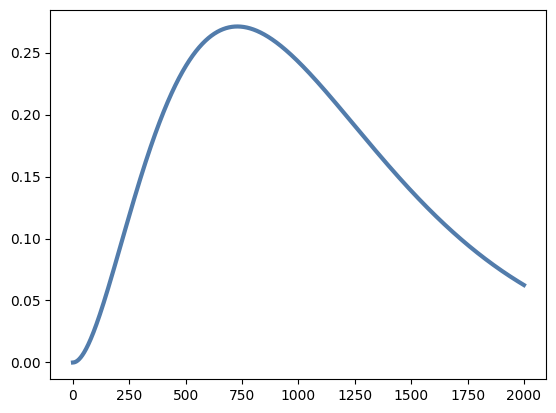

In [ ]:
# Solution goes here
from scipy.stats import binom
import matplotlib.pyplot as plt

p = 1/365
likelihood_2 = binom.pmf(2, hypos, p) # 2 people being born on May 11.
plt.plot(hypos, likelihood_2);

Now, we can perform the first Bayesian update:

In [ ]:
# Solution goes here
posterior = prior.copy()
posterior *= likelihood_2
posterior.normalize()

np.float64(0.2053515873513333)

Similarly, we can perform the second Bayesian update.

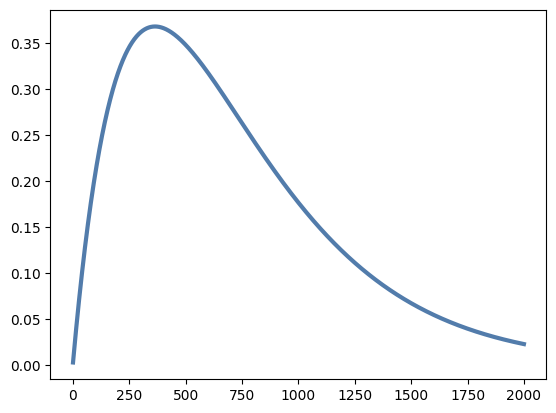

In [ ]:
# Solution goes here
likelihood_1 = binom.pmf(1, hypos, p) # 1 person being born on May 23.
plt.plot(hypos, likelihood_1);

In [ ]:
# Solution goes here
posterior *= likelihood_1
posterior.normalize()

np.float64(0.20411914089338476)

And the third Bayesian update.

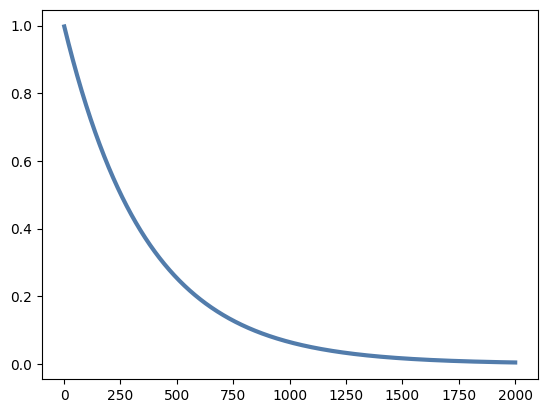

In [ ]:
# Solution goes here
likelihood_0 = binom.pmf(0, hypos, p) # 0 people being born on Aug 1.
plt.plot(hypos, likelihood_0);

In [ ]:
# Solution goes here
posterior *= likelihood_0
posterior.normalize()

np.float64(0.15259111948207596)

Let's visualize the posterior.

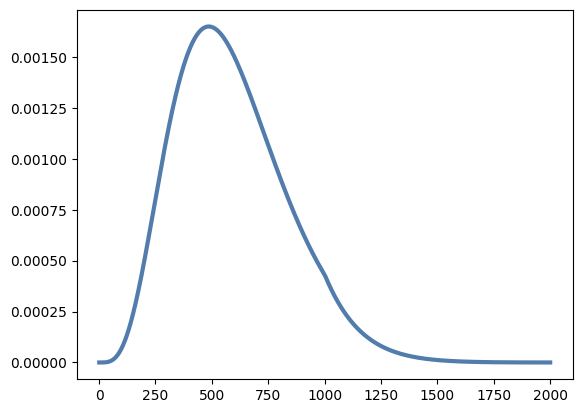

In [ ]:
# Solution goes here
posterior.plot();

Estimate of the number of people in the audience:

In [ ]:
# Solution goes here
posterior.mean()

np.float64(589.4823873476951)

Finally, let's calculate the probability mass of values greater than `1200`.

In [ ]:
# Solution goes here
1 - posterior.prob_le(1200)

np.float64(0.01529426878420248)

The probability is approximately 1.5%.

**Exercise:** I often see [rabbits](https://en.wikipedia.org/wiki/Eastern_cottontail) in the garden behind my house, but it's not easy to tell them apart, so I don't really know how many there are.

Suppose I deploy a motion-sensing [camera trap](https://en.wikipedia.org/wiki/Camera_trap) that takes a picture **of the first rabbit it sees each day**.  After three days, I compare the **(three)** pictures and conclude that two of them are the same rabbit and the other is different.

How many rabbits visit my garden?

To answer this question, we have to think about the prior distribution and the likelihood of the data:

* I have sometimes seen four rabbits at the same time, so I know there are at least that many.  I would be surprised if there were more than 10.  So, at least as a starting place, I think a uniform prior from 4 to 10 is reasonable.

* To keep things simple, let's assume that all rabbits who visit my garden are equally likely to be caught by the camera trap in a given day.  Let's also assume it is guaranteed that the camera trap gets a picture every day.

In [ ]:
# Solution goes here
hypos = np.arange(4, 11)
prior = Pmf(1, hypos)
prior.normalize()
prior

,0
4,0.142857
5,0.142857
6,0.142857
7,0.142857
8,0.142857
9,0.142857
10,0.142857


Let's consider the data from the perspective of the rabbit who was trapped twice. Let's model that particular rabbit getting trapped as a binary outcome.

Since all the rabbits are equally likely to be trapped **on a particular day**:

In [ ]:
# Solution goes here
ps = 1 / hypos
ps

array([0.25      , 0.2       , 0.16666667, 0.14285714, 0.125     ,
       0.11111111, 0.1       ])

There is one value of $p$ for each hypothesis. But there were `3` trials and `2` successes. (This is the *data*.) So we can obtain the likelihoods as follows:

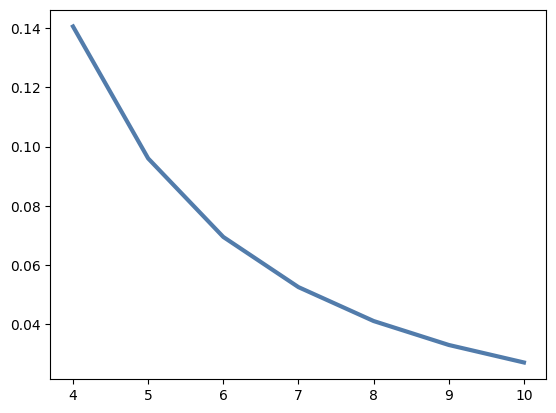

In [ ]:
# Solution goes here
likelihood = binom.pmf(2, 3, ps)
plt.plot(hypos, likelihood);

Now, let's compute the posterior.

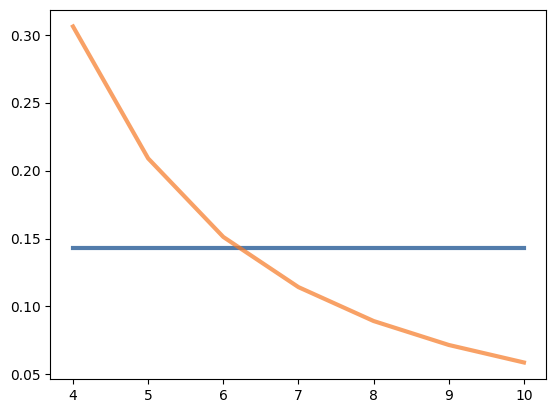

In [ ]:
# Solution goes here
posterior = prior * likelihood
posterior.normalize()
prior.plot()
posterior.plot();

Let's use the expectation of the posterior distribution as our point estimate of the number of rabbits.

In [ ]:
# Solution goes here
posterior.mean()

np.float64(5.92170542526008)

The 90% credible interval isn't very useful in this case:

In [ ]:
# Solution goes here
posterior.credible_interval(0.9)

array([ 4., 10.])

**Exercise:** Suppose that in the criminal justice system, all prison sentences are either 1, 2, or 3 years, with an equal number of each.  One day, you visit a prison and choose a prisoner at random.  What is the probability that they are serving a 3-year sentence?  What is the average remaining sentence of the prisoners you observe?

In [ ]:
# Solution goes here
qs = [1, 2, 3]
pmf = Pmf(1, qs)
pmf.normalize()
pmf

,0
1,0.333333
2,0.333333
3,0.333333


What is the *data* (evidence)? In the absence of evidence, this is not a Bayes' Theorem exercise at all.

It seems to be an exercise testing our knowledge of mean (*expected value*) of a probability distribution.

Probability that a randomly chosen prisoner is serving a 3-year sentence:

In [ ]:
# Solution goes here
pmf(3)

np.float64(0.3333333333333333)

We don't know how much of their prison sentence each prisoner has served. To calculate the average remaining sentence, we shall assume that on average, the prisoners have served half of their prison sentences.

In [ ]:
# Solution goes here
remaining_qs = [0.5, 1, 1.5]
remaining_pmf = Pmf(1, remaining_qs)
remaining_pmf.normalize()
remaining_pmf

,0
0.5,0.333333
1.0,0.333333
1.5,0.333333


Average remaining sentence:

In [ ]:
# Solution goes here
remaining_pmf.mean()

np.float64(1.0)

**Exercise:** If I chose a random adult in the U.S., what is the probability that they have a sibling?  To be precise, what is the probability that their mother has had at least one other child.

[This article from the Pew Research Center](https://www.pewsocialtrends.org/2015/05/07/family-size-among-mothers/) provides some relevant data.  

From it, I extracted the following distribution of family size for mothers in the U.S. who were 40-44 years old in 2014:

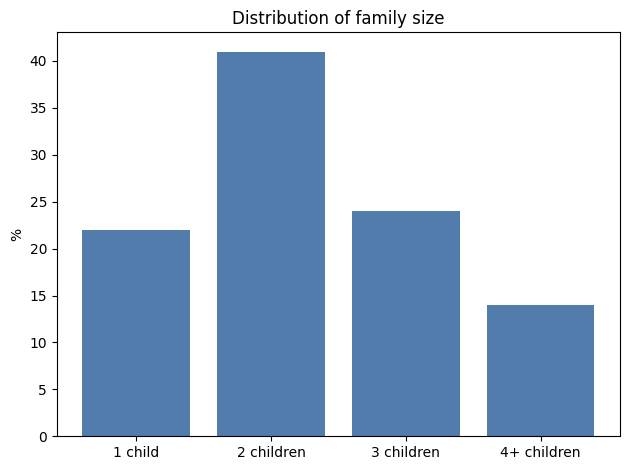

In [ ]:
import matplotlib.pyplot as plt

qs = [1, 2, 3, 4]
ps = [22, 41, 24, 14] # These are percentages.
prior = Pmf(ps, qs)
prior.bar(alpha=0.7)

plt.xticks(qs, ['1 child', '2 children', '3 children', '4+ children'])
decorate(ylabel='%', title='Distribution of family size')

For simplicity, let's assume that all families in the 4+ category have exactly 4 children.

In [ ]:
# Solution goes here
qs = [1, 2, 3, 4]
ps = [0.22, 0.41, 0.24, 0.14]
prior = Pmf(ps, qs)
prior

,0
1,0.22
2,0.41
3,0.24
4,0.14


In [ ]:
# Solution goes here
prior.sum()

np.float64(1.01)

The probabilities aren't adding up to `1`. Let's correct that.

In [ ]:
# Solution goes here
prior.normalize()
prior

,0
1,0.217822
2,0.405941
3,0.237624
4,0.138614


We now have a valid probability distribution:

In [ ]:
# Solution goes here
prior.sum()

np.float64(1.0)

Probability of having a sibling:

In [ ]:
# Solution goes here
prior.prob_ge(2)

np.float64(0.7821782178217821)

**Exercise:** The [Doomsday argument](https://en.wikipedia.org/wiki/Doomsday_argument) is "a probabilistic argument that claims to predict the number of future members of the human species given an estimate of the total number of humans born so far."

Suppose there are only two kinds of intelligent civilizations that can happen in the universe.  The "short-lived" kind go exinct after only 200 billion individuals are born.  The "long-lived" kind survive until 2,000 billion individuals are born.
And suppose that the two kinds of civilization are equally likely.
Which kind of civilization do you think we live in?  

The Doomsday argument says we can use the total number of humans born so far as data.
According to the [Population Reference Bureau](https://www.prb.org/howmanypeoplehaveeverlivedonearth/), the total number of people who have ever lived is about 108 billion.

Since you were born quite recently, let's assume that you are, in fact, human being number 108 billion.
If $N$ is the total number who will ever live and we consider you to be a randomly-chosen person, it is equally likely that you could have been person 1, or $N$, or any number in between.
So what is the probability that you would be number 108 billion?

Given this data and dubious prior, what is the probability that our civilization will be short-lived?

In [ ]:
# Solution goes here
hypos = np.array([200e+9, 2000e+9])
prior = Pmf(1, hypos)
prior.normalize()
prior

,0
2.000000e+11,0.5
2.000000e+12,0.5


Which civilization do I think we live in? It's hard to say. Being an optimist, I'll pick the "long-lived" kind.

We can calculate the likelihoods based on the following information:

> "Since you were born quite recently, let's assume that you are, in fact, human being number 108 billion. If  𝑁  is the total number who will ever live and we consider you to be a randomly-chosen person, it is equally likely that you could have been person 1, or  𝑁 , or any number in between."

The probability that I would be number 108 billion, given each hypothesis is:

In [ ]:
# Solution goes here
likelihood_108b = 1 / hypos
likelihood_108b

array([5.e-12, 5.e-13])

In [ ]:
# Solution goes here
posterior = prior * likelihood_108b
posterior.normalize()
posterior

,0
2.000000e+11,0.909091
2.000000e+12,0.090909


Probability that our civilization will be short-lived:

In [ ]:
# Solution goes here
posterior(200e+9)

np.float64(0.9090909090909091)

**Question:** At the end of the chapter, a question comes to mind. In the train problem, when the observer sees train `60`, the *explicit data* is `60`, but the *implicit data* is `1, 2, ..., 59, 60`? This is because if train `60` exists, then surely trains `1, 2, ..., 59` also exist. Therefore, when the observer sees train `60`, shouldn't he do `60` Bayesian updates? A very similar question may be asked in the context of the German tank problem. And in the above exercise pertaining to the Doomsday argument, shouldn't there be 108 billion Bayesian updates?

**Answers:**

- https://chat.qwen.ai/s/e38bb1f4-af6f-41d0-a23d-e7006fe69c3c?fev=0.2.35
- https://gemini.google.com/share/b03eb539f278

Insightful parts of Gemini's explanation:

> **Existence vs. Observation**

> When you say "seeing 60 implies 1 through 59 exist," you are correct. However, in this model, the existence of those trains is already baked into the definition of the hypothesis $H$. (In other words, if the hypothesis is $H = 100$, it doesn't mean that train 100 exists; it means that trains 1, 2, ..., 100 exist.)

> The "data" (evidence) is not the fact that trains 1, 2, ..., 60 exist; the data is the random outcome that, out of all possible trains you could have seen, you saw number 60.

...

> **The Small Train Example**

> Imagine a tiny railroad. You know they number their trains $1, 2, \dots, N$. You have three hypotheses for how many trains they own:

- H1: They have 1 train ($N=1$)
- H2: They have 2 trains ($N=2$)
- H3: They have 3 trains ($N=3$)

> **Prior:** You think each is equally likely (1/3 each).

> **The Data:** You walk outside and see Train #2.

...

> **Why we don't do "Two Updates"**

> Your intuition suggests we should do one update for seeing #2, and one for the fact that #1 exists. Let’s see what happens if we try that.

> **Update A: "I saw Train #2"**

> This update is where the actual "weight" (**discriminatory power**) comes from. This is a random observation.

- H1 ($N=1$) gets ruled out immediately, since the "data" is Train #2.
- The likelihoods of the remaining hypotheses (H2 and H3) is given by $1/N$.

> This is the only update that actually shifts the balance among the possibilities.

> **Update B: "Train #1 exists"**

> Let's think about the likelihoods. What is the probability that Train #1 exists given each hypothesis?

- In H2 ($N=2$), the probability that Train #1 exists is 1.0 (it’s a rule).
- In H3 ($N=3$), the probability that Train #1 exists is 1.0 (it’s a rule).

> If you multiply your prior probabilities by 1.0, nothing changes. The relative weight between H2 and H3 remains exactly the same. (In other words, this hypothetical Bayesian update has **zero discriminatory power**.)

> Hopefully, seeing the difference between "an actual observation" (likelihood $1/N$) and "a fact that is a logical implication of an observation" (likelihood 1.0) helps clarify why we only update once.

- https://chatgpt.com/share/69d232fb-ce08-83ab-873b-baf025a3c4c6

Insightful parts of ChatGPT's explanation:

> Seeing train **60** already includes the fact that trains **1 through 59 exist**, but those facts are **logically implied** by the one observation. In Bayesian inference, you should update on the data **once**, using the likelihood for the whole observation. You do not get to count all the logical consequences as additional independent evidence.

...

> If you tried to update separately on:

- “train 1 exists”
- “train 2 exists”
- ...
- “train 60 exists”

> you would be pretending these are 60 distinct pieces of evidence. They are not. Once you know train 60 exists, the others follow automatically. Evidence that is logically entailed by other evidence does not get multiplied in again. That's because those are not new observations. They are just logical consequences of the one observation.

> A simpler analogy:

- If I tell you “I have a 10-story building,” you also learn that floors 1 through 9 exist.
- You would not update once for “10 floors exist,” then again for “floor 9 exists,” then again for “floor 8 exists,” etc.

> Those are not new data points.

...

> **What does seeing train 60 tell us?**

> It tells us two kinds of things:

> **Explicitly**

> You saw a train labeled 60.

> **Implicitly**

> If the railroad numbers trains sequentially from 1 to $N$, then train 60 cannot exist unless trains 1 through 59 also exist.

> So yes: from seeing 60, you can infer that 1 through 59 exist.

> That part of your reasoning is correct.

> But the key question is:

> Does “inferring that trains 1 through 59 exist” give 59 extra pieces of evidence?

> And the answer is no, because those are not new observations. They are just logical consequences of the one observation.

...

> **A very simple analogy**

> Suppose I tell you:

> “I met the 10th employee hired by a company.”

> From that, you can infer that employees 1 through 9 must also have existed.

> Would it make sense to say:

- one update for employee 10 existing,
- another for employee 9 existing,
- another for employee 8 existing,
- ...
- another for employee 1 existing?

> No, because all of that came from **one fact**.

> You learned only one thing from the world. The rest was deduction.

> Bayesian updating uses the probability of **the data you actually observed**, not the data plus all its logical consequences counted again and again.

...

> Seeing train 60 is not equivalent to seeing trains 1 through 60.

> It is equivalent to learning:

> “There are at least 60 trains, and the one I happened to observe was #60.”

> That is one observation, and its likelihood is $1/N$.

*Think Bayes*, Second Edition

Copyright 2020 Allen B. Downey

License: [Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/)